In [ ]:
import cv2
import numpy as np
from pathlib import Path

dir_path = Path('E:/la_trobe/raw_data/train/Autistic/')
samples = list(dir_path.rglob('*.jpg'))[:100]
noise_levels = []
brightness = []
for img_path in samples:
    img = cv2.imread(str(img_path), 0)
    noise_levels.append(np.std(img))  # 噪聲指標
    brightness.append(np.mean(img))  # 亮度指標


if noise_levels:
    avg_noise = np.mean(noise_levels)
    avg_brightness = np.mean(brightness)
    need_denoise = np.mean(np.array(noise_levels) > 15) * 100
    need_brightness = np.mean((np.array(brightness) < 100) | (np.array(brightness) > 180)) * 100

print(f"平均噪聲: {avg_noise:.2f}, 需去噪比例: {need_denoise:.1f}%")#average noise
print(f"平均亮度: {avg_brightness:.2f}, 需亮度調整比例: {need_brightness:.1f}%")#average brightness

平均噪聲: 58.87, 需去噪比例: 100.0%
平均亮度: 135.76, 需亮度調整比例: 2.0%


In [5]:
import cv2
from pathlib import Path

input_dir = Path('E:/la_trobe/raw_data/train/Non_Autistic/')
output_dir = Path('E:/la_trobe/raw_data/clean/Non_Autistic/')

output_dir.parent.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(exist_ok=True)
print(f"輸出目錄創建成功: {output_dir}")

# 初始化計數變數
processed_count = 0
failed_count = 0

for img_path in input_dir.rglob('*.jpg'):
    img = cv2.imread(str(img_path))

    if img is not None:
        # 去噪
        denoised = cv2.medianBlur(img, 5)

        # # 亮度調整 (CLAHE)
        # lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
        # l, a, b = cv2.split(lab)
        # clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        # cl = clahe.apply(l)
        # merged = cv2.merge((cl, a, b))
        # cleaned = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

        # 儲存
        out_path = output_dir / img_path.name
        cv2.imwrite(str(out_path), denoised)


        processed_count += 1
        if processed_count % 100 == 0:
            print(f"已處理 {processed_count} 張圖像...")

print(f"清洗完成，總處理 {processed_count} 張圖像.失敗 {failed_count} 張,輸出至: {output_dir}")

輸出目錄創建成功: E:\la_trobe\raw_data\clean\Non_Autistic
已處理 100 張圖像...
已處理 200 張圖像...
已處理 300 張圖像...
已處理 400 張圖像...
已處理 500 張圖像...
已處理 600 張圖像...
已處理 700 張圖像...
已處理 800 張圖像...
已處理 900 張圖像...
已處理 1000 張圖像...
已處理 1100 張圖像...
已處理 1200 張圖像...
已處理 1300 張圖像...
已處理 1400 張圖像...
已處理 1500 張圖像...
已處理 1600 張圖像...
已處理 1700 張圖像...
已處理 1800 張圖像...
已處理 1900 張圖像...
已處理 2000 張圖像...
已處理 2100 張圖像...
已處理 2200 張圖像...
已處理 2300 張圖像...
已處理 2400 張圖像...
已處理 2500 張圖像...
已處理 2600 張圖像...
已處理 2700 張圖像...
已處理 2800 張圖像...
已處理 2900 張圖像...
已處理 3000 張圖像...
已處理 3100 張圖像...
已處理 3200 張圖像...
已處理 3300 張圖像...
已處理 3400 張圖像...
已處理 3500 張圖像...
已處理 3600 張圖像...
已處理 3700 張圖像...
已處理 3800 張圖像...
已處理 3900 張圖像...
已處理 4000 張圖像...
已處理 4100 張圖像...
已處理 4200 張圖像...
已處理 4300 張圖像...
清洗完成，總處理 4363 張圖像.失敗 0 張,輸出至: E:\la_trobe\raw_data\clean\Non_Autistic


In [3]:
from skimage.metrics import structural_similarity as ssim
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import os

# 定義路徑
input_dir = Path('E:/la_trobe/raw_data/train/Autistic/')  # 原始
output_dir = Path('E:/la_trobe/raw_data/clean/Autistic/')  # 清洗

# 獲取配對檔案
original_files = sorted([f for f in input_dir.rglob('*.jpg')])
cleaned_files = sorted([f for f in output_dir.rglob('*.jpg')])

# 初始化結果列表
results = []

# 檢查檔案數量與不配對檔案
print(f"原始檔案數: {len(original_files)}")
print(f"清洗檔案數: {len(cleaned_files)}")

if len(original_files) != len(cleaned_files):
    print("不配對檔案檢查:")
    orig_names = set(f.name for f in original_files)
    clean_names = set(f.name for f in cleaned_files)
    missing_in_clean = orig_names - clean_names
    extra_in_clean = clean_names - orig_names
    print(f"原始中有但清洗中無 (前 10): {list(missing_in_clean)[:10]}")
    print(f"清洗中有但原始中無 (前 10): {list(extra_in_clean)[:10]}")

    # 記錄不配對檔案至結果
    for missing in missing_in_clean:
        results.append({
            'Original_File': missing,
            'Cleaned_File': None,
            'SSIM_Score': None,
            'Status': 'Missing in cleaned'
        })
    for extra in extra_in_clean:
        results.append({
            'Original_File': None,
            'Cleaned_File': extra,
            'SSIM_Score': None,
            'Status': 'Extra in cleaned'
        })
else:
    print("檔案數匹配，開始 SSIM 比較。")

    scores = []
    for orig_path, clean_path in zip(original_files, cleaned_files):
        orig_img = cv2.imread(str(orig_path), 0)  # 灰度圖
        clean_img = cv2.imread(str(clean_path), 0)  # 灰度圖

        if orig_img is not None and clean_img is not None and orig_img.shape == clean_img.shape:
            score = ssim(orig_img, clean_img, data_range=clean_img.max() - clean_img.min())
            scores.append(score)
            results.append({
                'Original_File': orig_path.name,
                'Cleaned_File': clean_path.name,
                'SSIM_Score': score,
                'Status': 'Valid'
            })
            print(f"{orig_path.name} SSIM: {score:.3f}")
        else:
            results.append({
                'Original_File': orig_path.name,
                'Cleaned_File': clean_path.name,
                'SSIM_Score': None,
                'Status': 'Invalid (shape mismatch or read failed)'
            })
            print(f"跳過 {orig_path.name}: 形狀不匹配或讀取失敗")

    if scores:
        avg_score = np.mean(scores)
        std_score = np.std(scores)
        print(f"\nBatch comparison results:")
        print(f"Total Pairs: {len(scores)}")
        print(f"Average SSIM: {avg_score:.3f} (Std: {std_score:.3f})")
        print(f"Ideal Range: >0.9 (High Structure Similarity)")

        # 繪製直方圖
        plt.figure(figsize=(8, 5))
        plt.hist(scores, bins=20, edgecolor='black', alpha=0.7)
        plt.axvline(avg_score, color='red', linestyle='--', label=f'Mean: {avg_score:.3f}')
        plt.xlabel('SSIM Score')
        plt.ylabel('Frequency')
        plt.title('SSIM Distribution of Original vs. Cleaned Images')
        plt.legend()
        plt.savefig('E:/la_trobe/cleaned/', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("無有效配對圖像，請檢查路徑或檔案。")

# 保存結果至 CSV
output_csv = Path('E:/la_trobe/cleaned/asd_ssim_results.csv')
output_csv.parent.mkdir(parents=True, exist_ok=True)
results_df = pd.DataFrame(results)
results_df.to_csv(output_csv, index=False)
print(f"SSIM 結果已保存至: {output_csv}")

ImportError: cannot import name 'uniform_filter' from 'scipy.ndimage' (unknown location)

In [6]:
import cv2
from pathlib import Path

input_dir = Path('E:/la_trobe/raw_data/clean/Non_Autistic/')
output_dir = Path('E:/la_trobe/raw_data/cleaned/Non_Autistic/')

output_dir.parent.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(exist_ok=True)
print(f"輸出目錄創建成功: {output_dir}")

# 初始化計數變數
processed_count = 0
failed_count = 0

for img_path in input_dir.rglob('*.jpg'):
    img = cv2.imread(str(img_path))

    if img is not None:
        # 去噪
        denoised = cv2.medianBlur(img, 5)

        # 亮度調整 (CLAHE)
        lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        cl = clahe.apply(l)
        merged = cv2.merge((cl, a, b))
        cleaned = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

        # 儲存
        out_path = output_dir / img_path.name
        cv2.imwrite(str(out_path), cleaned)


        processed_count += 1
        if processed_count % 100 == 0:
            print(f"已處理 {processed_count} 張圖像...")

print(f"清洗完成，總處理 {processed_count} 張圖像.失敗 {failed_count} 張,輸出至: {output_dir}")

輸出目錄創建成功: E:\la_trobe\raw_data\cleaned\Non_Autistic
已處理 100 張圖像...
已處理 200 張圖像...
已處理 300 張圖像...
已處理 400 張圖像...
已處理 500 張圖像...
已處理 600 張圖像...
已處理 700 張圖像...
已處理 800 張圖像...
已處理 900 張圖像...
已處理 1000 張圖像...
已處理 1100 張圖像...
已處理 1200 張圖像...
已處理 1300 張圖像...
已處理 1400 張圖像...
已處理 1500 張圖像...
已處理 1600 張圖像...
已處理 1700 張圖像...
已處理 1800 張圖像...
已處理 1900 張圖像...
已處理 2000 張圖像...
已處理 2100 張圖像...
已處理 2200 張圖像...
已處理 2300 張圖像...
已處理 2400 張圖像...
已處理 2500 張圖像...
已處理 2600 張圖像...
已處理 2700 張圖像...
已處理 2800 張圖像...
已處理 2900 張圖像...
已處理 3000 張圖像...
已處理 3100 張圖像...
已處理 3200 張圖像...
已處理 3300 張圖像...
已處理 3400 張圖像...
已處理 3500 張圖像...
已處理 3600 張圖像...
已處理 3700 張圖像...
已處理 3800 張圖像...
已處理 3900 張圖像...
已處理 4000 張圖像...
已處理 4100 張圖像...
已處理 4200 張圖像...
已處理 4300 張圖像...
清洗完成，總處理 4363 張圖像.失敗 0 張,輸出至: E:\la_trobe\raw_data\cleaned\Non_Autistic


原始檔案數: 40
清洗檔案數: 40
檔案數匹配，開始 SSIM 比較。
01.jpg SSIM: 0.890
02.jpg SSIM: 0.875
03.jpg SSIM: 0.883
04.jpg SSIM: 0.876
05.jpg SSIM: 0.870
06.jpg SSIM: 0.861
07.jpg SSIM: 0.882
08.jpg SSIM: 0.858
09.jpg SSIM: 0.891
10.jpg SSIM: 0.885
11.jpg SSIM: 0.892
12.jpg SSIM: 0.884
13.jpg SSIM: 0.892
14.jpg SSIM: 0.902
15.jpg SSIM: 0.916
16.jpg SSIM: 0.901
17.jpg SSIM: 0.878
18.jpg SSIM: 0.863
19.jpg SSIM: 0.911
20.jpg SSIM: 0.871
21.jpg SSIM: 0.879
22.jpg SSIM: 0.868
23.jpg SSIM: 0.886
24.jpg SSIM: 0.860
25.jpg SSIM: 0.884
26.jpg SSIM: 0.895
27.jpg SSIM: 0.864
28.jpg SSIM: 0.900
29.jpg SSIM: 0.881
30.jpg SSIM: 0.881
31.jpg SSIM: 0.884
32.jpg SSIM: 0.881
33.jpg SSIM: 0.904
34.jpg SSIM: 0.886
35.jpg SSIM: 0.893
36.jpg SSIM: 0.868
37.jpg SSIM: 0.879
38.jpg SSIM: 0.892
39.jpg SSIM: 0.874
40.jpg SSIM: 0.911

Batch comparison results:
Total Pairs: 40
Average SSIM: 0.884 (Std: 0.014)
Ideal Range: >0.9 (High Structure Similarity)


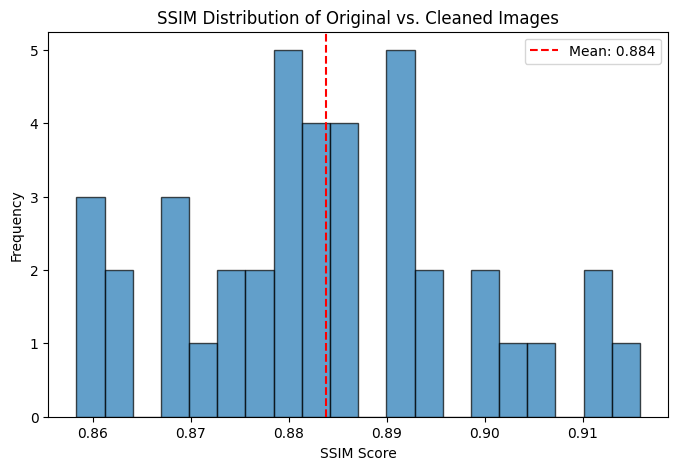

SSIM 結果已保存至: E:\la_trobe\autism_models\data\clean\clean_two\valid\Autistic\asd_ssim_results.csv


In [43]:
from skimage.metrics import structural_similarity as ssim
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import os

# 定義路徑
input_dir = Path('E:/la_trobe/autism_models/data/clean/clean_one/valid/Autistic')  # 原始
output_dir = Path('E:/la_trobe/autism_models/data/clean/clean_two/valid/Autistic')  # 清洗

# 獲取配對檔案
original_files = sorted([f for f in input_dir.rglob('*.jpg')])
cleaned_files = sorted([f for f in output_dir.rglob('*.jpg')])

# 初始化結果列表
results = []

# 檢查檔案數量與不配對檔案
print(f"原始檔案數: {len(original_files)}")
print(f"清洗檔案數: {len(cleaned_files)}")

if len(original_files) != len(cleaned_files):
    print("不配對檔案檢查:")
    orig_names = set(f.name for f in original_files)
    clean_names = set(f.name for f in cleaned_files)
    missing_in_clean = orig_names - clean_names
    extra_in_clean = clean_names - orig_names
    print(f"原始中有但清洗中無 (前 10): {list(missing_in_clean)[:10]}")
    print(f"清洗中有但原始中無 (前 10): {list(extra_in_clean)[:10]}")

    # 記錄不配對檔案至結果
    for missing in missing_in_clean:
        results.append({
            'Original_File': missing,
            'Cleaned_File': None,
            'SSIM_Score': None,
            'Status': 'Missing in cleaned'
        })
    for extra in extra_in_clean:
        results.append({
            'Original_File': None,
            'Cleaned_File': extra,
            'SSIM_Score': None,
            'Status': 'Extra in cleaned'
        })
else:
    print("檔案數匹配，開始 SSIM 比較。")

    scores = []
    for orig_path, clean_path in zip(original_files, cleaned_files):
        orig_img = cv2.imread(str(orig_path), 0)  # 灰度圖
        clean_img = cv2.imread(str(clean_path), 0)  # 灰度圖

        if orig_img is not None and clean_img is not None and orig_img.shape == clean_img.shape:
            score = ssim(orig_img, clean_img, data_range=clean_img.max() - clean_img.min())
            scores.append(score)
            results.append({
                'Original_File': orig_path.name,
                'Cleaned_File': clean_path.name,
                'SSIM_Score': score,
                'Status': 'Valid'
            })
            print(f"{orig_path.name} SSIM: {score:.3f}")
        else:
            results.append({
                'Original_File': orig_path.name,
                'Cleaned_File': clean_path.name,
                'SSIM_Score': None,
                'Status': 'Invalid (shape mismatch or read failed)'
            })
            print(f"跳過 {orig_path.name}: 形狀不匹配或讀取失敗")

    if scores:
        avg_score = np.mean(scores)
        std_score = np.std(scores)
        print(f"\nBatch comparison results:")
        print(f"Total Pairs: {len(scores)}")
        print(f"Average SSIM: {avg_score:.3f} (Std: {std_score:.3f})")
        print(f"Ideal Range: >0.9 (High Structure Similarity)")

        # 繪製直方圖
        plt.figure(figsize=(8, 5))
        plt.hist(scores, bins=20, edgecolor='black', alpha=0.7)
        plt.axvline(avg_score, color='red', linestyle='--', label=f'Mean: {avg_score:.3f}')
        plt.xlabel('SSIM Score')
        plt.ylabel('Frequency')
        plt.title('SSIM Distribution of Original vs. Cleaned Images')
        plt.legend()
        plt.savefig('E:/la_trobe/autism_models/data/clean/clean_two/valid/Autistic/asd_ssim_histogram.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("無有效配對圖像，請檢查路徑或檔案。")

# 保存結果至 CSV
output_csv = Path('E:/la_trobe/autism_models/data/clean/clean_two/valid/Autistic/asd_ssim_results.csv')
output_csv.parent.mkdir(parents=True, exist_ok=True)
results_df = pd.DataFrame(results)
results_df.to_csv(output_csv, index=False)
print(f"SSIM 結果已保存至: {output_csv}")

In [44]:
import cv2
import numpy as np
from pathlib import Path

dir_path = Path('E:/la_trobe/autism_models/data/valid/Non_Autistic')
samples = list(dir_path.rglob('*.jpg'))[:100]
noise_levels = []
brightness = []
for img_path in samples:
    img = cv2.imread(str(img_path), 0)
    noise_levels.append(np.std(img))  # 噪聲指標
    brightness.append(np.mean(img))  # 亮度指標


if noise_levels:
    avg_noise = np.mean(noise_levels)
    avg_brightness = np.mean(brightness)
    need_denoise = np.mean(np.array(noise_levels) > 15) * 100
    need_brightness = np.mean((np.array(brightness) < 100) | (np.array(brightness) > 180)) * 100

print(f"平均噪聲: {avg_noise:.2f}, 需去噪比例: {need_denoise:.1f}%")
print(f"平均亮度: {avg_brightness:.2f}, 需亮度調整比例: {need_brightness:.1f}%")


平均噪聲: 47.49, 需去噪比例: 100.0%
平均亮度: 153.60, 需亮度調整比例: 20.5%


In [45]:
import cv2
from pathlib import Path

input_dir = Path('E:/la_trobe/autism_models/data/valid/Non_Autistic')
output_dir = Path('E:/la_trobe/autism_models/data/clean/clean_one/valid/Non_Autistic')

output_dir.parent.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(exist_ok=True)
print(f"輸出目錄創建成功: {output_dir}")

# 初始化計數變數
processed_count = 0
failed_count = 0

for img_path in input_dir.rglob('*.jpg'):
    img = cv2.imread(str(img_path))

    if img is not None:
        # 去噪
        denoised = cv2.medianBlur(img, 5)

        # # 亮度調整 (CLAHE)
        # lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
        # l, a, b = cv2.split(lab)
        # clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        # cl = clahe.apply(l)
        # merged = cv2.merge((cl, a, b))
        # cleaned = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

        # 儲存
        out_path = output_dir / img_path.name
        cv2.imwrite(str(out_path), denoised)


        processed_count += 1
        if processed_count % 100 == 0:
            print(f"已處理 {processed_count} 張圖像...")

print(f"清洗完成，總處理 {processed_count} 張圖像.失敗 {failed_count} 張,輸出至: {output_dir}")

輸出目錄創建成功: E:\la_trobe\autism_models\data\clean\clean_one\valid\Non_Autistic
清洗完成，總處理 39 張圖像.失敗 0 張,輸出至: E:\la_trobe\autism_models\data\clean\clean_one\valid\Non_Autistic


原始檔案數: 39
清洗檔案數: 39
檔案數匹配，開始 SSIM 比較。
01.jpg SSIM: 0.794
02.jpg SSIM: 0.932
03.jpg SSIM: 0.931
04.jpg SSIM: 0.858
05.jpg SSIM: 0.869
06.jpg SSIM: 0.905
07.jpg SSIM: 0.822
08.jpg SSIM: 0.911
09.jpg SSIM: 0.936
10.jpg SSIM: 0.891
11.jpg SSIM: 0.948
12.jpg SSIM: 0.793
13.jpg SSIM: 0.898
14.jpg SSIM: 0.862
15.jpg SSIM: 0.942
16.jpg SSIM: 0.956
17.jpg SSIM: 0.923
18.jpg SSIM: 0.904
19.jpg SSIM: 0.976
20.jpg SSIM: 0.931
21.jpg SSIM: 0.863
22.jpg SSIM: 0.946
23.jpg SSIM: 0.953
24.jpg SSIM: 0.933
25.jpg SSIM: 0.796
26.jpg SSIM: 0.830
27.jpg SSIM: 0.780
28.jpg SSIM: 0.933
29.jpg SSIM: 0.891
30.jpg SSIM: 0.946
31.jpg SSIM: 0.839
32.jpg SSIM: 0.717
34.jpg SSIM: 0.820
35.jpg SSIM: 0.950
36.jpg SSIM: 0.898
37.jpg SSIM: 0.891
38.jpg SSIM: 0.890
39.jpg SSIM: 0.962
40.jpg SSIM: 0.973

Batch comparison results:
Total Pairs: 39
Average SSIM: 0.892 (Std: 0.061)
Ideal Range: >0.9 (High Structure Similarity)


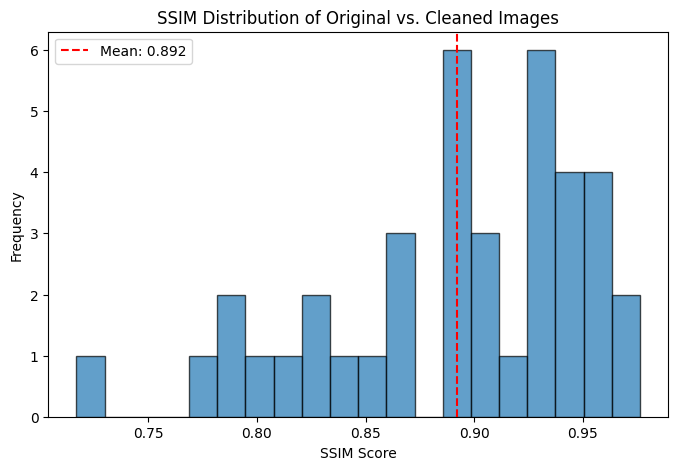

SSIM 結果已保存至: E:\la_trobe\autism_models\data\clean\clean_one\valid\Non_Autistic\non-asd_ssim_results.csv


In [46]:
from skimage.metrics import structural_similarity as ssim
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import os

# 定義路徑
input_dir = Path('E:/la_trobe/autism_models/data/valid/Non_Autistic')  # 原始
output_dir = Path('E:/la_trobe/autism_models/data/clean/clean_one/valid/Non_Autistic')  # 清洗

# 獲取配對檔案
original_files = sorted([f for f in input_dir.rglob('*.jpg')])
cleaned_files = sorted([f for f in output_dir.rglob('*.jpg')])

# 初始化結果列表
results = []

# 檢查檔案數量與不配對檔案
print(f"原始檔案數: {len(original_files)}")
print(f"清洗檔案數: {len(cleaned_files)}")

if len(original_files) != len(cleaned_files):
    print("不配對檔案檢查:")
    orig_names = set(f.name for f in original_files)
    clean_names = set(f.name for f in cleaned_files)
    missing_in_clean = orig_names - clean_names
    extra_in_clean = clean_names - orig_names
    print(f"原始中有但清洗中無 (前 10): {list(missing_in_clean)[:10]}")
    print(f"清洗中有但原始中無 (前 10): {list(extra_in_clean)[:10]}")

    # 記錄不配對檔案至結果
    for missing in missing_in_clean:
        results.append({
            'Original_File': missing,
            'Cleaned_File': None,
            'SSIM_Score': None,
            'Status': 'Missing in cleaned'
        })
    for extra in extra_in_clean:
        results.append({
            'Original_File': None,
            'Cleaned_File': extra,
            'SSIM_Score': None,
            'Status': 'Extra in cleaned'
        })
else:
    print("檔案數匹配，開始 SSIM 比較。")

    scores = []
    for orig_path, clean_path in zip(original_files, cleaned_files):
        orig_img = cv2.imread(str(orig_path), 0)  # 灰度圖
        clean_img = cv2.imread(str(clean_path), 0)  # 灰度圖

        if orig_img is not None and clean_img is not None and orig_img.shape == clean_img.shape:
            score = ssim(orig_img, clean_img, data_range=clean_img.max() - clean_img.min())
            scores.append(score)
            results.append({
                'Original_File': orig_path.name,
                'Cleaned_File': clean_path.name,
                'SSIM_Score': score,
                'Status': 'Valid'
            })
            print(f"{orig_path.name} SSIM: {score:.3f}")
        else:
            results.append({
                'Original_File': orig_path.name,
                'Cleaned_File': clean_path.name,
                'SSIM_Score': None,
                'Status': 'Invalid (shape mismatch or read failed)'
            })
            print(f"跳過 {orig_path.name}: 形狀不匹配或讀取失敗")

    if scores:
        avg_score = np.mean(scores)
        std_score = np.std(scores)
        print(f"\nBatch comparison results:")
        print(f"Total Pairs: {len(scores)}")
        print(f"Average SSIM: {avg_score:.3f} (Std: {std_score:.3f})")
        print(f"Ideal Range: >0.9 (High Structure Similarity)")

        # 繪製直方圖
        plt.figure(figsize=(8, 5))
        plt.hist(scores, bins=20, edgecolor='black', alpha=0.7)
        plt.axvline(avg_score, color='red', linestyle='--', label=f'Mean: {avg_score:.3f}')
        plt.xlabel('SSIM Score')
        plt.ylabel('Frequency')
        plt.title('SSIM Distribution of Original vs. Cleaned Images')
        plt.legend()
        plt.savefig('E:/la_trobe/autism_models/data/clean/clean_one/valid/Non_Autistic/non-asd_ssim_histogram.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("無有效配對圖像，請檢查路徑或檔案。")

# 保存結果至 CSV
output_csv = Path('E:/la_trobe/autism_models/data/clean/clean_one/valid/Non_Autistic/non-asd_ssim_results.csv')
output_csv.parent.mkdir(parents=True, exist_ok=True)
results_df = pd.DataFrame(results)
results_df.to_csv(output_csv, index=False)
print(f"SSIM 結果已保存至: {output_csv}")

In [47]:
import cv2
from pathlib import Path

input_dir = Path('E:/la_trobe/autism_models/data/clean/clean_one/valid/Non_Autistic/')
output_dir = Path('E:/la_trobe/autism_models/data/clean/clean_two/valid/Non_Autistic/')

output_dir.parent.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(exist_ok=True)
print(f"輸出目錄創建成功: {output_dir}")

# 初始化計數變數
processed_count = 0
failed_count = 0

for img_path in input_dir.rglob('*.jpg'):
    img = cv2.imread(str(img_path))

    if img is not None:
        # 去噪
        denoised = cv2.medianBlur(img, 5)

        # 亮度調整 (CLAHE)
        lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        cl = clahe.apply(l)
        merged = cv2.merge((cl, a, b))
        cleaned = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

        # 儲存
        out_path = output_dir / img_path.name
        cv2.imwrite(str(out_path), cleaned)


        processed_count += 1
        if processed_count % 100 == 0:
            print(f"已處理 {processed_count} 張圖像...")

print(f"清洗完成，總處理 {processed_count} 張圖像.失敗 {failed_count} 張,輸出至: {output_dir}")

輸出目錄創建成功: E:\la_trobe\autism_models\data\clean\clean_two\valid\Non_Autistic
清洗完成，總處理 39 張圖像.失敗 0 張,輸出至: E:\la_trobe\autism_models\data\clean\clean_two\valid\Non_Autistic
